# FACT Demo: Mesoscopic Imaging

This notebook runs the FACT pipeline on the mesoscopic imaging demo. 

Data: `data\Demo\Meso\Data_meso_strip.tif`

In [1]:
import gc
import sys
import time
from pathlib import Path

import SimpleITK as sitk
import numpy as np
import torch

PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from IO.Read_tif import load_tiff
from ModelInference.SWInf import sliding_window_inference
from PostSlice.PostProcess_Pipeline import (
    Post_FACT_guided_backgroundremoving,
    Post_additional_morphological_blocks,
    Post_standard_spatial_consolidation,
    extract_roi_mean_traces,
)
from PreProcessing.Auto_normalization import estimate_display_range_video
from UI.Combine import combine_masks
from model.TS_Net_change import FACT_Net

ROI_SIZE = (128, 64, 64)
MAX_SW_BATCH_SIZE = 32

def _is_cuda_oom(error):
    return isinstance(error, torch.cuda.OutOfMemoryError) or (
        isinstance(error, RuntimeError) and "out of memory" in str(error).lower()
    )

def _release_cuda_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def get_auto_sw_batch_size(
    roi_size=ROI_SIZE,
    max_batch_size=MAX_SW_BATCH_SIZE,
    reserved_ratio=0.25,
    mem_per_patch_mb=705,
    device=None,
):
    del roi_size
    target_device = (
        torch.device(device)
        if device is not None
        else torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    )
    if target_device.type != "cuda" or not torch.cuda.is_available():
        return 1
    torch.cuda.empty_cache()
    free_bytes, total_bytes = torch.cuda.mem_get_info(target_device)
    safety_ratio = min(max(float(reserved_ratio), 0.0), 0.95)
    usable_bytes = max(0, int(float(free_bytes) * (1.0 - safety_ratio)))
    mem_per_patch = max(1, int(mem_per_patch_mb)) * 1024 * 1024
    estimated_batch = int(usable_bytes // mem_per_patch)
    batch_size = max(1, min(int(max_batch_size), estimated_batch))
    print(
        "Auto sw_batch_size: {} (free VRAM ~{:.1f}/{:.1f} GB)".format(
            batch_size, float(free_bytes) / 1024**3, float(total_bytes) / 1024**3
        )
    )
    return batch_size

print(f"Release root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")

Release root: FACT-Code-Release
Python: fact_pub1\python.exe


### Load data

In [2]:
DATASET_NAME = "Data_meso_strip"
DATA_PATH = PROJECT_ROOT / "data" / "Demo" / "Meso" / f"{DATASET_NAME}.tif"
MODEL_PATH = PROJECT_ROOT / "ModelParams" / "FACT_Modelparams.pt"
data_path = str(DATA_PATH)
print(f"Dataset: {DATASET_NAME}")
print(f"TIFF: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Dataset: Data_meso_strip
TIFF: data\Demo\Meso\Data_meso_strip.tif


In [3]:
time_start = time.perf_counter()
input_img = np.asarray(load_tiff(str(DATA_PATH)), dtype=np.float32)
norm_min, norm_max = estimate_display_range_video(input_img)
denom = float(norm_max - norm_min)
if denom <= 0:
    denom = 1.0
input_img = np.clip(
    (input_img.astype(np.float64) - norm_min) / denom, 0.0, 1.0
).astype(np.float32)
print(f"Loaded normalized video: shape={input_img.shape}, dtype={input_img.dtype}")
print(f"Estimated normalization range: [{norm_min:.6g}, {norm_max:.6g}]")
print(f"Read/normalize seconds: {time.perf_counter() - time_start:.2f}")

Loaded normalized video: shape=(1000, 1800, 600), dtype=float32
Estimated normalization range: [155.707, 478.562]
Read/normalize seconds: 31.92


### Load FACT network

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Inference device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

def _build_fact_model(target_device):
    fact_model = FACT_Net(
        img_size=ROI_SIZE,
        in_channels=1,
        out_channels=2,
        init_dim=3,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        use_checkpoint=True,
    ).to(target_device)
    weight = torch.load(str(MODEL_PATH), map_location="cpu", weights_only=False)
    fact_model.load_state_dict(weight["state_dict"])
    fact_model.eval()
    return fact_model

try:
    model = _build_fact_model(device)
except RuntimeError as error:
    if device.type != "cuda" or not _is_cuda_oom(error):
        raise
    _release_cuda_memory()
    device = torch.device("cpu")
    model = _build_fact_model(device)

print(f"Loaded model: {MODEL_PATH.relative_to(PROJECT_ROOT)}")

Inference device: cuda:0
GPU: NVIDIA GeForce RTX 3090


Loaded model: ModelParams\FACT_Modelparams.pt


### Network Inference

In [5]:
time_start = time.perf_counter()
sw_batch_size = get_auto_sw_batch_size(device=device)
# This matches the default Dense Mode inference preset: reflect-pad 64 frames on
# each temporal side, use overlap (0.6, 0.6, 0.6) with Gaussian blending, and
# crop the prediction back to the original temporal extent.
input_img_padded = np.pad(input_img, ((64, 64), (0, 0), (0, 0)), mode="reflect")

def _run_inference_once(batch_size):
    input_img_tensor = torch.from_numpy(input_img_padded)
    test_inputs = input_img_tensor.unsqueeze(0).unsqueeze(1)
    with torch.no_grad():
        test_outputs = sliding_window_inference(
            test_inputs,
            ROI_SIZE,
            sw_batch_size=int(batch_size),
            predictor=model,
            overlap=[0.6, 0.6, 0.6],
            progress=True,
            mode="gaussian",
            device=torch.device("cpu"),
            sw_device=device,
        )
        frame_count = input_img.shape[0]
        test_outputs = test_outputs[:, :, 64 : 64 + frame_count, :, :]
        diff = test_outputs[0, 1] - test_outputs[0, 0]
        infer_mask3d_local = (diff > -2).to(dtype=torch.uint8).cpu().numpy()
    del test_outputs, diff, test_inputs, input_img_tensor
    return infer_mask3d_local

while True:
    try:
        infer_mask3d = _run_inference_once(sw_batch_size)
        break
    except RuntimeError as error:
        if device.type != "cuda" or not _is_cuda_oom(error):
            raise
        _release_cuda_memory()
        if sw_batch_size > 1:
            previous_batch_size = sw_batch_size
            estimated_batch_size = get_auto_sw_batch_size(device=device)
            sw_batch_size = min(max(1, previous_batch_size // 2), estimated_batch_size)
            print(f"CUDA OOM at sw_batch_size={previous_batch_size}; retrying with sw_batch_size={sw_batch_size}.")
            continue
        model = model.to(torch.device("cpu"))
        device = torch.device("cpu")
        _release_cuda_memory()
        sw_batch_size = 1
        infer_mask3d = _run_inference_once(sw_batch_size)
        break

del input_img_padded
if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()
print(f"Network inference complete: infer_mask3d={infer_mask3d.shape}")
print(f"Inference sw_batch_size used: {sw_batch_size}")
print(f"Inference device used: {device}")
print(f"Inference seconds: {time.perf_counter() - time_start:.2f}")

Auto sw_batch_size: 24 (free VRAM ~22.7/24.0 GB)


  0%|          | 0/1429 [00:00<?, ?it/s]

torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
None of the inputs have requires_grad=True. Gradients will be None


  0%|          | 1/1429 [00:05<2:18:30,  5.82s/it]

  0%|          | 2/1429 [00:06<1:06:23,  2.79s/it]

...

100%|█████████▉| 1427/1429 [11:55<00:00,  2.19it/s]

100%|█████████▉| 1428/1429 [11:56<00:00,  2.20it/s]

100%|██████████| 1429/1429 [11:56<00:00,  2.27it/s]

100%|██████████| 1429/1429 [11:56<00:00,  1.99it/s]

Network inference complete: infer_mask3d=(1000, 1800, 600)
Inference sw_batch_size used: 24
Inference device used: cuda:0
Inference seconds: 722.25


### Calculate STD

In [6]:
T, H, W = (int(value) for value in infer_mask3d.shape)
mask_shape_2d = (H, W)
infer_mask3d = np.asarray(infer_mask3d, dtype=np.uint8)
std_raw = np.std(input_img, axis=0, dtype=np.float64)
std_min = float(std_raw.min())
std_max = float(std_raw.max())
if std_max <= std_min:
    std_img = np.zeros((H, W), dtype=np.float32)
else:
    std_img = ((std_raw - std_min) / (std_max - std_min) * 255.0).astype(np.float32)
del std_raw
gc.collect()
print(f"Postprocess mask shape: {mask_shape_2d}; frames: {T}")

Postprocess mask shape: (1800, 600); frames: 1000


## Post-processing

In [7]:
POST_PARAMS = {
    "max_area": 200,
    "min_area": 30,
    "thresh_com": 4.0,
    "thresh_com_refine": 7.0,
    "thresh_iou": 0.7,
    "thresh_consume": 0.85,
    "thresh_acti": 2,
    "thresh_refine": 0.1,
    "num_workers": 8,
}
post_start = time.perf_counter()
masks_final, timestamps_final = Post_standard_spatial_consolidation(
    infer_mask3d,
    mask_shape_2d=mask_shape_2d,
    min_area=POST_PARAMS["min_area"],
    max_area=POST_PARAMS["max_area"],
    thresh_com=POST_PARAMS["thresh_com"],
    thresh_com_refine=POST_PARAMS["thresh_com_refine"],
    thresh_refine=POST_PARAMS["thresh_refine"],
    thresh_iou=POST_PARAMS["thresh_iou"],
    thresh_consume=POST_PARAMS["thresh_consume"],
    thresh_acti=POST_PARAMS["thresh_acti"],
    num_workers=POST_PARAMS["num_workers"],
)
masks_final = (masks_final.tocsr() > 0).astype(np.int64)
print(f"Spatial postprocess complete: masks={masks_final.shape[0]}")
print(f"Postprocess seconds: {time.perf_counter() - post_start:.2f}")

The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12030. The TBB threading layer is disabled.


Finding mask pairs


Calculating transfered masks


Spatial postprocess complete: masks=1728
Postprocess seconds: 29.50


In [8]:
masks_final, _, _ = Post_additional_morphological_blocks(
    masks_final,
    mask_shape_2d,
    timestamps=timestamps_final,
    sc1=False,
    sc2=True,
    sc2_params=[0.4, 2.5, 0.4, 2.5],
    sc3=False,
    sc4=True,
    sc4_min_area=POST_PARAMS["min_area"],
    binarize_after_each=True,
)
masks_final = (masks_final.tocsr() > 0).astype(np.int64)
areas = np.asarray(masks_final.getnnz(axis=1)).ravel()
mean_area = areas.mean() if areas.size > 0 else 0.0
print(f"Morphological postprocess complete: masks={masks_final.shape[0]}")
print(f"Average mask area: {mean_area:.2f}")

Morphological postprocess complete: masks=1626
Average mask area: 130.49


In [9]:
masks_for_trace = (masks_final.tocsr() > 0).astype(np.int64)
traces_roi_init = extract_roi_mean_traces(masks_for_trace, input_img)
sources = np.zeros((masks_for_trace.shape[0],), dtype=bool)
background_result = Post_FACT_guided_backgroundremoving(
    masks_for_trace,
    traces_roi_init,
    sources,
    infer_mask3d=infer_mask3d,
    input_img=input_img,
    mask_shape_2d=mask_shape_2d,
    run_overlap_demix=False,
    binarize_final=True,
)
masks_final = (background_result["masks_final"].tocsr() > 0).astype(np.int64)
traces_roi = np.asarray(background_result["traces_cell"], dtype=np.float32)
traces_background = np.asarray(background_result["traces_bg"], dtype=np.float32)
traces_final = np.asarray(background_result["traces_final"], dtype=np.float32)
sources = np.asarray(background_result["sources"], dtype=bool).reshape(-1)
alpha_nnls = np.asarray(background_result["alpha_nnls"], dtype=np.float32).reshape(-1)
del masks_for_trace, traces_roi_init, background_result
gc.collect()
print(f"Trace extraction and background removal complete: masks={masks_final.shape[0]}, traces={traces_final.shape}")

Trace extraction and background removal complete: masks=1626, traces=(1626, 1000)


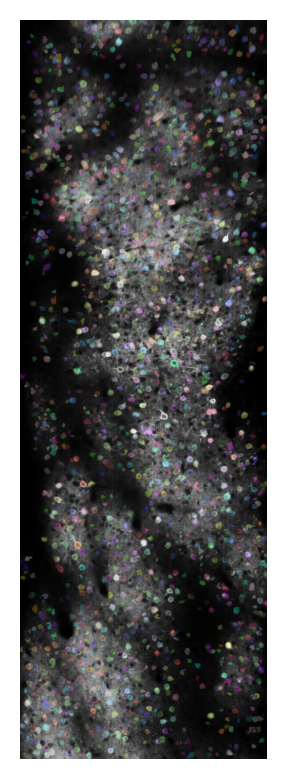

In [10]:
import matplotlib.pyplot as plt
from PostSlice.UI.Drawmap import draw_mask_colormap

showmap = draw_mask_colormap(masks_final, mask_shape_2d)
show_combined = combine_masks(showmap, std_img, alpha=0.3, brightness_factor=1, mask_threshold=1)
plt.figure(dpi=200)
plt.imshow(show_combined)
plt.axis("off")
plt.show()

## Interactive exhibition of masks and traces

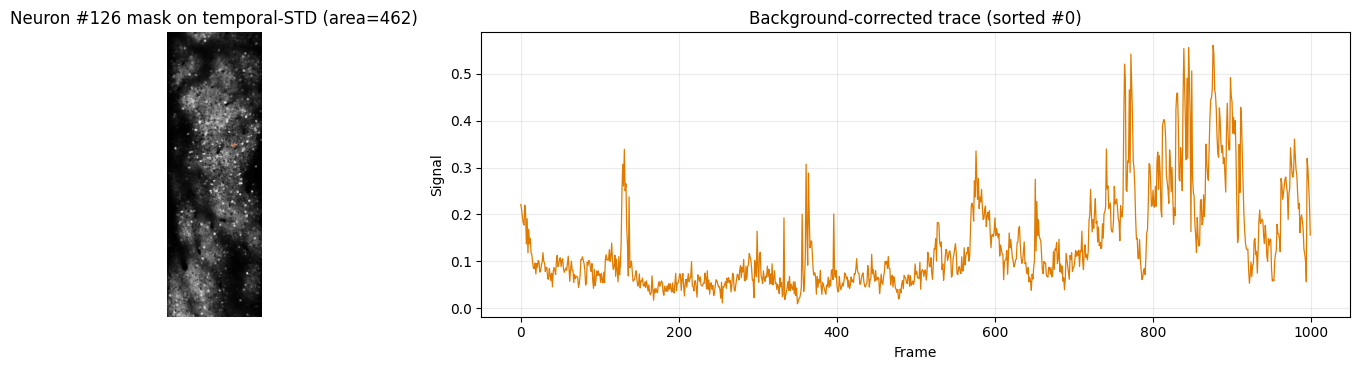

In [11]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def _single_mask_flat(mask_array, row_index):
    row = mask_array.getrow(int(row_index))
    return np.asarray(row.toarray()).ravel()

def _warm_color(row_index):
    hue = (0.035 + 0.11 * ((int(row_index) * 37) % 101) / 100.0) % 1.0
    return (mcolors.hsv_to_rgb((hue, 0.90, 1.0)) * 255.0).astype(np.float32)

def _overlay_for_row(row_index):
    mask = _single_mask_flat(masks_final, row_index).reshape(mask_shape_2d) > 0
    gray = np.clip(std_img, 0.0, 255.0).astype(np.float32)
    overlay = np.repeat(gray[..., None], 3, axis=2)
    color = _warm_color(row_index)
    overlay[mask] = 0.5 * overlay[mask] + 0.5 * color
    return np.clip(overlay, 0, 255).astype(np.uint8), mask

mask_areas = np.asarray(masks_final.getnnz(axis=1)).ravel()
sorted_neuron_indices = np.argsort(mask_areas)[::-1]
neuron_count = int(masks_final.shape[0])

def show_single_neuron(sorted_idx):
    sorted_idx = int(sorted_idx)
    neuron_idx = int(sorted_neuron_indices[sorted_idx])
    overlay, mask = _overlay_for_row(neuron_idx)
    trace = np.asarray(traces_final[neuron_idx]).ravel()
    fig, axes = plt.subplots(1, 2, figsize=(16, 3.8))
    axes[0].imshow(overlay)
    axes[0].set_title(f"Neuron #{neuron_idx} mask on temporal-STD (area={int(mask_areas[neuron_idx])})")
    axes[0].axis("off")
    axes[1].plot(trace, lw=0.9, color="#e07b00")
    axes[1].set_title(f"Background-corrected trace (sorted #{sorted_idx})")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("Signal")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

show_single_neuron(0)
neuron_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=neuron_count - 1,
    step=1,
    description="Sorted#",
    continuous_update=False,
)
viewer_output = widgets.interactive_output(
    show_single_neuron, {"sorted_idx": neuron_slider}
)
display(widgets.VBox([neuron_slider, viewer_output]))